# Refactored Hybrid Model: PhoBERT + TF-IDF Light Fusion\n\n## Design goals\n1. Keep PhoBERT close to the strong baseline by using the CLS token directly.\n2. Keep TF-IDF as a lightweight auxiliary lexical signal.\n3. Compare simple concatenation against optional gated fusion.\n4. Make class weighting and selection metrics easy to change.


## 1. Setup và Import Libraries

In [1]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [2]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, preprocess_vietnamese

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [3]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    MODEL_TYPE = 'PhoBERT_TFIDF_Refactored_LightFusion'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')
    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    MAX_LENGTH = 256
    BATCH_SIZE = 16
    DROPOUT = 0.3
    FUSION_MODE = 'concat'
    # TF-IDF settings - MUST match pretrained checkpoint
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True
    TFIDF_REDUCTION = 'lsa'
    TFIDF_LSA_COMPONENTS = 256
    TFIDF_LSA_N_ITER = 10
    TFIDF_LSA_RANDOM_STATE = 42
    TFIDF_PROJ_DIM = 96
    CLASSIFIER_HIDDEN_DIM = 256
    # Pretrained checkpoint path
    PRETRAINED_CKPT = os.path.join(BASE_DIR, 'results', 'PhoBERT_TFIDF_Refactored_LightFusion', 'improvements', '20260320_173649', 'models', 'best_model.pt')

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)

assert config.FUSION_MODE in {'concat', 'gated'}

print('=' * 60)
print('REFACTORED CONFIGURATION')
print('=' * 60)
print(f'Model: {config.MODEL_NAME}')
print(f'Fusion Mode: {config.FUSION_MODE}')
print(f'TF-IDF Reduction: {config.TFIDF_REDUCTION}')
print(f'TF-IDF LSA Components: {config.TFIDF_LSA_COMPONENTS}')
print(f'TF-IDF Projection Dim: {config.TFIDF_PROJ_DIM}')
print(f'Pretrained Checkpoint: {config.PRETRAINED_CKPT}')
print(f'Device: {config.DEVICE}')

REFACTORED CONFIGURATION
Model: vinai/phobert-base
Fusion Mode: concat
TF-IDF Reduction: lsa
TF-IDF LSA Components: 256
TF-IDF Projection Dim: 96
Pretrained Checkpoint: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_Refactored_LightFusion/improvements/20260320_173649/models/best_model.pt
Device: cuda


## 3. Load Data

In [4]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}: total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train: total=11426
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Validation: total=1583
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test: total=3166
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. TF-IDF Feature Extraction


In [5]:
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=config.TFIDF_MIN_DF,
    max_df=config.TFIDF_MAX_DF,
    sublinear_tf=config.TFIDF_SUBLINEAR_TF
)

train_tfidf_sparse = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf_sparse = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf_sparse = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)

lsa_explained_variance = None
lsa_components_used = None
if config.TFIDF_REDUCTION == 'lsa':
    # LSA gives a compact lexical summary, but too much compression may remove useful cues.
    max_lsa_dim = max(1, min(train_tfidf_sparse.shape[0] - 1, train_tfidf_sparse.shape[1] - 1))
    effective_lsa_dim = min(config.TFIDF_LSA_COMPONENTS, max_lsa_dim)
    tfidf_lsa = TruncatedSVD(
        n_components=effective_lsa_dim,
        n_iter=config.TFIDF_LSA_N_ITER,
        random_state=config.TFIDF_LSA_RANDOM_STATE
    )
    train_tfidf_features = tfidf_lsa.fit_transform(train_tfidf_sparse).astype(np.float32)
    val_tfidf_features = tfidf_lsa.transform(val_tfidf_sparse).astype(np.float32)
    test_tfidf_features = tfidf_lsa.transform(test_tfidf_sparse).astype(np.float32)
    lsa_explained_variance = float(tfidf_lsa.explained_variance_ratio_.sum())
    lsa_components_used = int(train_tfidf_features.shape[1])
    joblib.dump(tfidf_lsa, os.path.join(config.ARTIFACTS_DIR, 'tfidf_lsa.pkl'))
else:
    # Skipping LSA preserves all lexical dimensions, but the auxiliary head becomes larger.
    train_tfidf_features = train_tfidf_sparse.toarray().astype(np.float32)
    val_tfidf_features = val_tfidf_sparse.toarray().astype(np.float32)
    test_tfidf_features = test_tfidf_sparse.toarray().astype(np.float32)

tfidf_scaler = StandardScaler()
train_tfidf = tfidf_scaler.fit_transform(train_tfidf_features).astype(np.float32)
val_tfidf = tfidf_scaler.transform(val_tfidf_features).astype(np.float32)
test_tfidf = tfidf_scaler.transform(test_tfidf_features).astype(np.float32)
tfidf_input_dim = int(train_tfidf.shape[1])

joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(tfidf_scaler, os.path.join(config.ARTIFACTS_DIR, 'tfidf_scaler.pkl'))

print(f'TF-IDF sparse shapes: Train={train_tfidf_sparse.shape}, Val={val_tfidf_sparse.shape}, Test={test_tfidf_sparse.shape}')
print(f'TF-IDF dense shapes: Train={train_tfidf.shape}, Val={val_tfidf.shape}, Test={test_tfidf.shape}')
if lsa_explained_variance is not None:
    print(f'LSA components used: {lsa_components_used}')
    print(f'LSA explained variance ratio sum: {lsa_explained_variance:.4f}')
else:
    print('LSA disabled: using original TF-IDF space before the lightweight projection head.')


TF-IDF sparse shapes: Train=(11426, 5000), Val=(1583, 5000), Test=(3166, 5000)
TF-IDF dense shapes: Train=(11426, 256), Val=(1583, 256), Test=(3166, 256)
LSA components used: 256
LSA explained variance ratio sum: 0.5020


## 5. Dataset & Model Definition


In [6]:
class HybridDataset(Dataset):
    """Dataset for PhoBERT text inputs plus lightweight TF-IDF features."""
    def __init__(self, texts, tfidf_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tfidf = np.asarray(self.tfidf_features[idx], dtype=np.float32).ravel()
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [7]:
class PhoBERTTFIDFLightHybrid(nn.Module):
    """PhoBERT-first hybrid with a small auxiliary TF-IDF branch."""
    def __init__(self, model_name, tfidf_dim, num_classes, fusion_mode='concat', dropout=0.3):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.fusion_mode = fusion_mode
        phobert_dim = self.phobert.config.hidden_size
        self.phobert_dropout = nn.Dropout(dropout)
        self.tfidf_projection = nn.Sequential(
            nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM),
            nn.LayerNorm(config.TFIDF_PROJ_DIM),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        combined_dim = phobert_dim + config.TFIDF_PROJ_DIM
        if fusion_mode == 'gated':
            self.aux_gate = nn.Linear(combined_dim, config.TFIDF_PROJ_DIM)
            nn.init.constant_(self.aux_gate.bias, -1.0)
        else:
            self.aux_gate = None
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def get_head_modules(self):
        modules = [self.tfidf_projection, self.classifier]
        if self.aux_gate is not None:
            modules.append(self.aux_gate)
        return modules

    def forward(self, input_ids, attention_mask, tfidf_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        # Keep PhoBERT close to the baseline by using the native CLS representation directly.
        phobert_cls = self.phobert_dropout(outputs.last_hidden_state[:, 0, :])
        tfidf_proj = self.tfidf_projection(tfidf_features)
        if self.aux_gate is not None:
            gate = torch.sigmoid(self.aux_gate(torch.cat([phobert_cls, tfidf_proj], dim=1)))
            tfidf_proj = tfidf_proj * gate
        return self.classifier(torch.cat([phobert_cls, tfidf_proj], dim=1))


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFLightHybrid(
    model_name=config.MODEL_NAME,
    tfidf_dim=tfidf_input_dim,
    num_classes=config.NUM_CLASSES,
    fusion_mode=config.FUSION_MODE,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'TF-IDF input dim to model: {tfidf_input_dim}')
print(f'Total parameters: {total_params:,}')
print(f'Initial trainable parameters: {count_trainable_params(model):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TF-IDF input dim to model: 256
Total parameters: 135,245,347
Initial trainable parameters: 135,245,347


## 6. Create DataLoaders


In [8]:
train_dataset = HybridDataset(train_texts, train_tfidf.astype(np.float32), train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf.astype(np.float32), val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf.astype(np.float32), test_labels, tokenizer, config.MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
print(f'TF-IDF dense feature dim: {tfidf_input_dim}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')


TF-IDF dense feature dim: 256
Train batches: 715
Val batches: 99
Test batches: 198


<cell_type>markdown</cell_type>## 7. Evaluate Function

In [9]:
def evaluate(model, dataloader, device):
    """Evaluate model and return predictions and metrics."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf_features = batch['tfidf'].to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids, attention_mask, tfidf_features)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )
    return {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'classification_report_text': classification_report(all_labels, all_preds, labels=[0, 1, 2], target_names=list(config.LABEL_MAP.values()), zero_division=0),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }


def load_topics(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'topics.txt'), 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f.readlines()]


def load_checkpoint_safe(model_obj, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    cleaned = {}
    for k, v in state_dict.items():
        nk = k[7:] if k.startswith('module.') else k
        cleaned[nk] = v
    model_obj.load_state_dict(cleaned, strict=False)

<cell_type>markdown</cell_type>## 8. Load Pretrained Model and Get Topic-wise Results

Checkpoint duoc nap: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_Refactored_LightFusion/improvements/20260320_173649/models/best_model.pt


Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]


=== Overall Test Metrics ===
Accuracy: 0.9327
F1 Macro: 0.8226
F1 Weighted: 0.9291

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      1409
     Neutral       0.73      0.47      0.57       167
    Positive       0.94      0.96      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.87      0.79      0.82      3166
weighted avg       0.93      0.93      0.93      3166


=== Topic-wise Results ===


,topic_id,topic_name,samples,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0,Giang vien,2290,0.950218,0.816366,0.946929,0.952919,0.530973,0.965205
1,1,Chuong trinh dao tao,572,0.888112,0.760810,0.884464,0.943577,0.525000,0.813853
2,2,Co so vat chat,145,0.972414,0.568995,0.969408,0.992701,0.000000,0.714286
3,3,Khac,159,0.805031,0.789421,0.800317,0.865672,0.683544,0.819048



--- Topic 0 (Giang vien) ---
              precision    recall  f1-score   support

    Negative       0.95      0.96      0.95       791
     Neutral       0.77      0.41      0.53        74
    Positive       0.96      0.97      0.97      1425

    accuracy                           0.95      2290
   macro avg       0.89      0.78      0.82      2290
weighted avg       0.95      0.95      0.95      2290


--- Topic 1 (Chuong trinh dao tao) ---
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94       416
     Neutral       0.64      0.45      0.53        47
    Positive       0.77      0.86      0.81       109

    accuracy                           0.89       572
   macro avg       0.78      0.75      0.76       572
weighted avg       0.88      0.89      0.88       572


--- Topic 2 (Co so vat chat) ---
              precision    recall  f1-score   support

    Negative       1.00      0.99      0.99       138
     Neutral       0.00  

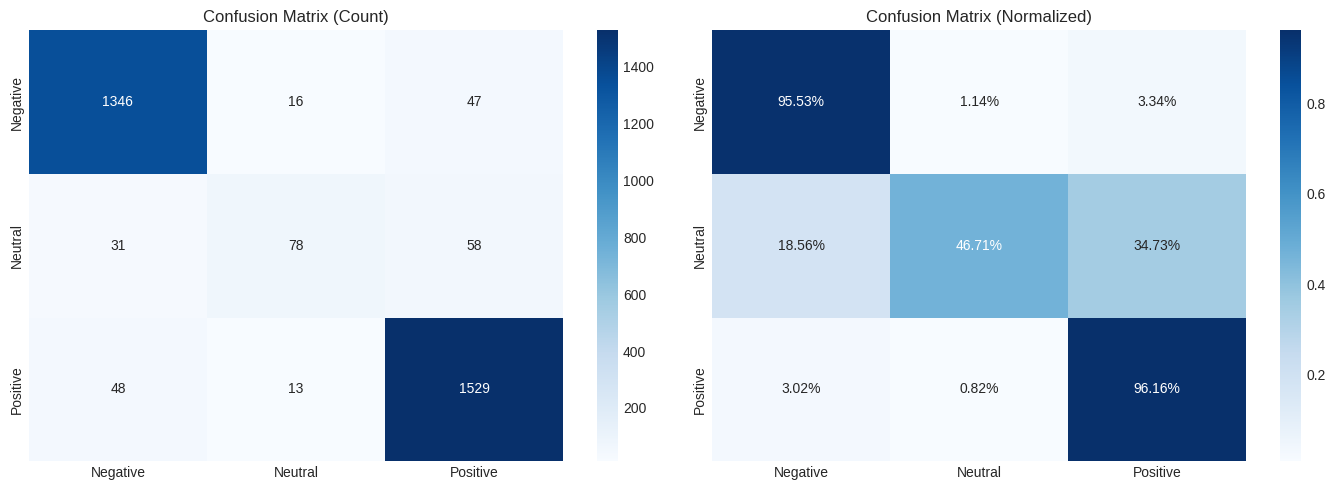

In [10]:
TOPIC_MAP = {0: 'Giang vien', 1: 'Chuong trinh dao tao', 2: 'Co so vat chat', 3: 'Khac'}

# Load pretrained checkpoint
ckpt_path = config.PRETRAINED_CKPT
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Khong tim thay checkpoint: {ckpt_path}')

print(f'Checkpoint duoc nap: {ckpt_path}')
load_checkpoint_safe(model, ckpt_path, config.DEVICE)
model.eval()

# Evaluate test set
test_results = evaluate(model, test_loader, config.DEVICE)
print('\n=== Overall Test Metrics ===')
print(f"Accuracy: {test_results['accuracy']:.4f}")
print(f"F1 Macro: {test_results['f1_macro']:.4f}")
print(f"F1 Weighted: {test_results['f1_weighted']:.4f}")
print('\nClassification Report:')
print(test_results['classification_report_text'])

# Topic-wise results
test_topics = load_topics(config.DATA_DIR, 'test')
if len(test_topics) != len(test_results['y_true']):
    raise ValueError(f'Mismatch do dai: topics={len(test_topics)} vs y_true={len(test_results["y_true"])}')

topic_df = pd.DataFrame({
    'topic': test_topics,
    'y_true': test_results['y_true'],
    'y_pred': test_results['y_pred']
})

topic_rows = []
for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    p, r, f1, support = precision_recall_fscore_support(
        sub['y_true'], sub['y_pred'], labels=[0, 1, 2], zero_division=0
    )
    topic_rows.append({
        'topic_id': int(topic_id),
        'topic_name': TOPIC_MAP.get(int(topic_id), str(topic_id)),
        'samples': int(len(sub)),
        'accuracy': float(accuracy_score(sub['y_true'], sub['y_pred'])),
        'f1_macro': float(f1_score(sub['y_true'], sub['y_pred'], average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(sub['y_true'], sub['y_pred'], average='weighted', zero_division=0)),
        'f1_negative': float(f1[0]),
        'f1_neutral': float(f1[1]),
        'f1_positive': float(f1[2]),
    })

print('\n=== Topic-wise Results ===')
topic_metrics_df = pd.DataFrame(topic_rows).sort_values('topic_id')
display(topic_metrics_df)

for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    print(f"\n--- Topic {topic_id} ({TOPIC_MAP.get(int(topic_id), str(topic_id))}) ---")
    print(classification_report(sub['y_true'], sub['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

# Save results
os.makedirs(config.SUMMARIES_DIR, exist_ok=True)
topic_metrics_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_metrics_from_pretrained.csv'), index=False)
topic_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_predictions_test.csv'), index=False)
print('\nDa luu file: topic_metrics_from_pretrained.csv, topic_predictions_test.csv')

# Confusion Matrix visualization
cm = np.array(test_results['confusion_matrix'])
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix_pretrained.png'), dpi=150, bbox_inches='tight')
plt.show()

## Topic-wise Visualizations

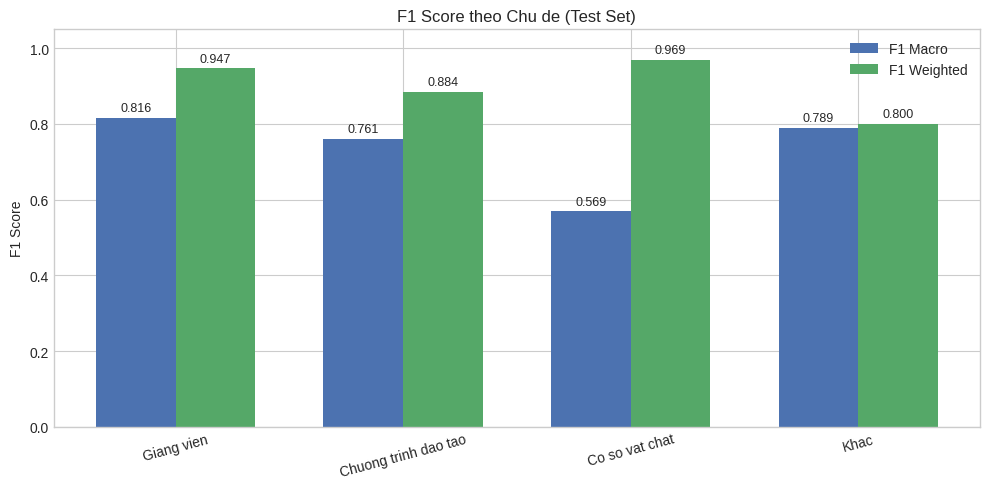

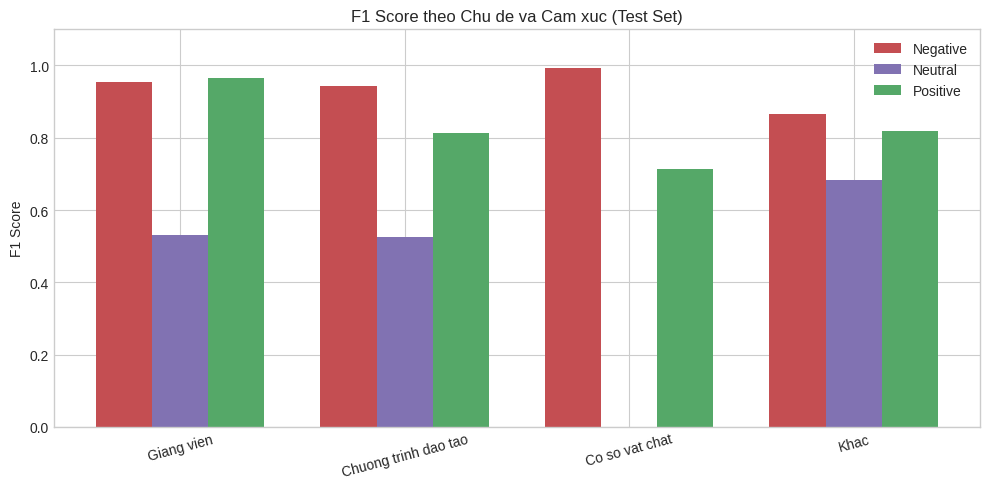

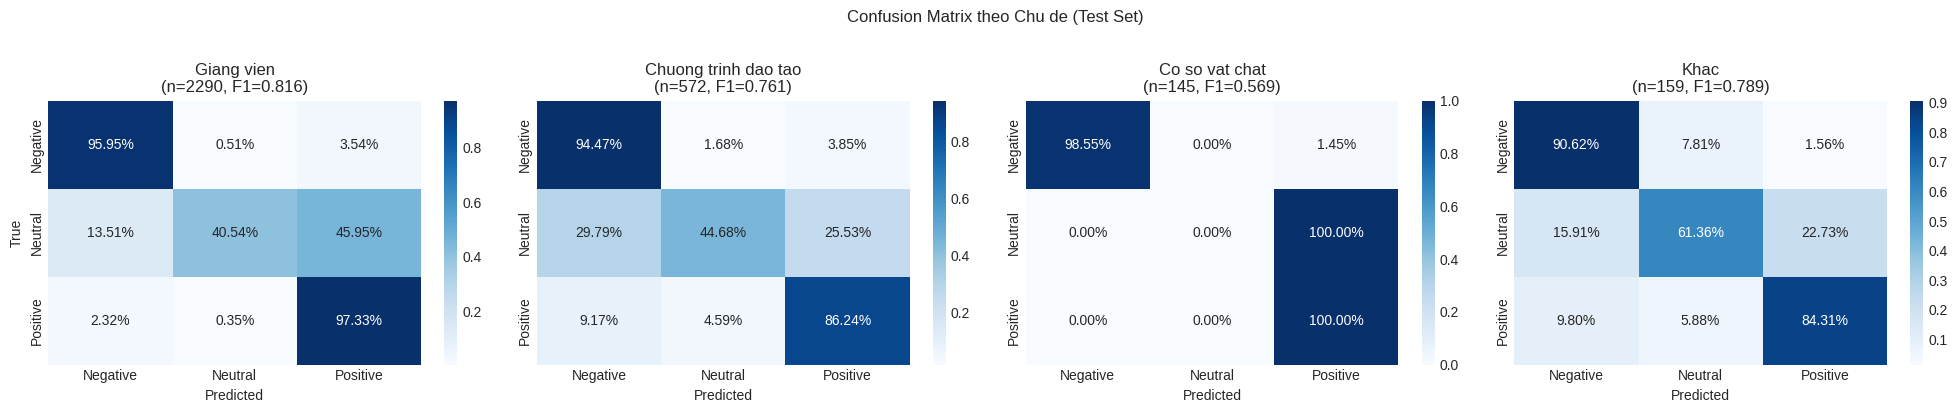

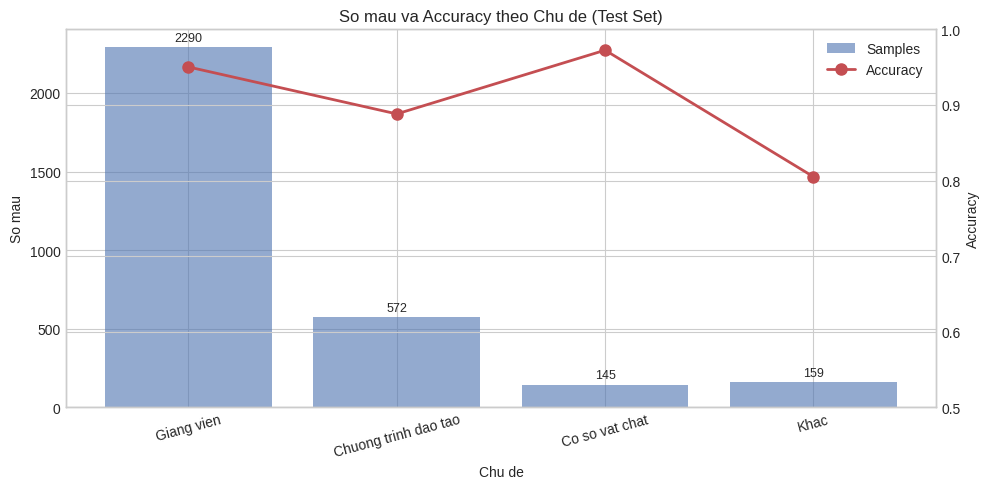

Da luu tat ca bieu do topic-wise vao: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_Refactored_LightFusion/improvements/20260329_083636/visualizations


In [11]:
# === Topic-wise visualizations ===

# 1) F1 macro/weighted per topic
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_metrics_df))
width = 0.35
bars1 = ax.bar(x - width/2, topic_metrics_df['f1_macro'], width, label='F1 Macro', color='#4C72B0')
bars2 = ax.bar(x + width/2, topic_metrics_df['f1_weighted'], width, label='F1 Weighted', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 Score theo Chu de (Test Set)')
ax.legend()
for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_f1_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2) Per-topic per-sentiment F1
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_metrics_df))
width = 0.25
ax.bar(x - width, topic_metrics_df['f1_negative'], width, label='Negative', color='#C44E52')
ax.bar(x, topic_metrics_df['f1_neutral'], width, label='Neutral', color='#8172B2')
ax.bar(x + width, topic_metrics_df['f1_positive'], width, label='Positive', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score theo Chu de va Cam xuc (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_sentiment_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3) Confusion matrix per topic
fig, axes = plt.subplots(1, len(topic_metrics_df), figsize=(5 * len(topic_metrics_df), 4))
label_names = list(config.LABEL_MAP.values())
for i, row in topic_metrics_df.iterrows():
    sub = topic_df[topic_df['topic'] == row['topic_id']]
    cm_topic = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1, 2])
    cm_topic_norm = cm_topic.astype(float) / cm_topic.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_topic_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[i])
    axes[i].set_title(f"{row['topic_name']}\n(n={row['samples']}, F1={row['f1_macro']:.3f})")
    if i == 0:
        axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrix theo Chu de (Test Set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# 4) Sample count + accuracy per topic
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(x, topic_metrics_df['samples'], color='#4C72B0', alpha=0.6, label='Samples')
ax1.set_ylabel('So mau')
ax1.set_xlabel('Chu de')
ax1.set_xticks(x)
ax1.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax2.plot(x, topic_metrics_df['accuracy'], 'o-', color='#C44E52', linewidth=2, markersize=8, label='Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.0)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.set_title('So mau va Accuracy theo Chu de (Test Set)')
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_samples_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Da luu tat ca bieu do topic-wise vao:', config.VISUALIZATIONS_DIR)